In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import time

# Đảm bảo hiển thị biểu đồ trên Colab
%matplotlib inline

In [3]:
# 1. Đường dẫn file
train_path = '/content/drive/MyDrive/Colab Notebooks/cs114/Data/train_clean.parquet'
val_path = '/content/drive/MyDrive/Colab Notebooks/cs114/Data/val_clean.parquet'
test_path = '/content/drive/MyDrive/Colab Notebooks/cs114/Data/test_clean.parquet'

# 2. Đọc dữ liệu
train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)
test_df = pd.read_parquet(test_path)

# 3. Label Mapping
label_mapping = {
    'business': 'business_finance', 'money': 'business_finance',
    'world': 'world_environment', 'environment': 'world_environment',
    'culture': 'culture_lifestyle', 'fashion': 'culture_lifestyle',
    'technology': 'tech_science_games', 'science': 'tech_science_games', 'games': 'tech_science_games',
    'sport': 'sport', 'film': 'film', 'music': 'music', 'food': 'food'
}

for df in [train_df, val_df, test_df]:
    df['label'] = df['label'].map(label_mapping).fillna(df['label'])
    df['text'] = df['title'].astype(str) + " " + df['article'].astype(str)

# 4. Encode Label
label_encoder = LabelEncoder()
train_df['label_id'] = label_encoder.fit_transform(train_df['label'])
val_df['label_id'] = label_encoder.transform(val_df['label'])
test_df['label_id'] = label_encoder.transform(test_df['label'])

print(f"Số lượng classes: {len(label_encoder.classes_)}")

Số lượng classes: 8


In [4]:
MAX_VOCAB_SIZE = 30000
MAX_SEQ_LENGTH = 512

def get_tokens(text):
    return re.findall(r'\b\w+\b', str(text).lower())

# 1. Tạo Vocabulary từ tập train
word_counts = Counter()
for text in train_df['text']:
    word_counts.update(get_tokens(text))

top_words = word_counts.most_common(MAX_VOCAB_SIZE)
word2idx = {'<PAD>': 0, '<UNK>': 1}
for idx, (word, _) in enumerate(top_words, start=2):
    word2idx[word] = idx

# 2. Hàm chuyển đổi Text -> List Indices (Đã padding)
def text_to_indices(text, word2idx, max_len):
    tokens = get_tokens(text)
    indices = [word2idx.get(w, word2idx['<UNK>']) for w in tokens]
    if len(indices) < max_len:
        indices = indices + [word2idx['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

# Áp dụng luôn lên DataFrame để tiết kiệm thời gian lúc training
print("Đang pre-process text sang dạng tensor...")
train_df['indices'] = train_df['text'].apply(lambda x: text_to_indices(x, word2idx, MAX_SEQ_LENGTH))
val_df['indices'] = val_df['text'].apply(lambda x: text_to_indices(x, word2idx, MAX_SEQ_LENGTH))
test_df['indices'] = test_df['text'].apply(lambda x: text_to_indices(x, word2idx, MAX_SEQ_LENGTH))
print("Hoàn tất!")

Đang pre-process text sang dạng tensor...
Hoàn tất!


In [5]:
class FastTextDataset(Dataset):
    def __init__(self, indices_list, labels):
        # Chuyển thẳng sang Tensor một lần duy nhất
        self.indices = torch.tensor(indices_list.tolist(), dtype=torch.long)
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.indices[idx], self.labels[idx]

BATCH_SIZE = 64

train_dataset = FastTextDataset(train_df['indices'], train_df['label_id'])
val_dataset = FastTextDataset(val_df['indices'], val_df['label_id'])
test_dataset = FastTextDataset(test_df['indices'], test_df['label_id'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, filter_sizes, num_filters, dropout_rate):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, x):
        embedded = self.embedding(x).permute(0, 2, 1)
        pooled_outputs = []
        for conv in self.convs:
            c = F.relu(conv(embedded))
            p = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2)
            pooled_outputs.append(p)

        x_cat = torch.cat(pooled_outputs, dim=1)
        return self.fc(self.dropout(x_cat))

In [7]:
def format_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

EMBED_DIM = 100
NUM_CLASSES = len(label_encoder.classes_)
FILTER_SIZES = [3, 4, 5]
NUM_FILTERS = 100
DROPOUT_RATE = 0.5
LEARNING_RATE = 2e-4
EPOCHS = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang train trên thiết bị: {device}")

vocab_size_real = len(word2idx)
model = TextCNN(vocab_size_real, EMBED_DIM, NUM_CLASSES, FILTER_SIZES, NUM_FILTERS, DROPOUT_RATE).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Arrays để vẽ biểu đồ loss và F1 macro
train_losses, val_losses, train_f1s, val_f1s = [], [], [], []

best_val_f1 = 0.0 # Dựa vào F1 Macro thay vì Acc để lưu model tốt nhất đối với bài toán đa lớp

print("Bắt đầu quá trình training...")
total_start_time = time.time() # Bắt đầu bấm giờ tổng thể

for epoch in range(EPOCHS):
    epoch_start_time = time.time() # Bấm giờ cho từng epoch

    # --- TRAINING ---
    model.train()
    total_loss = 0
    all_train_preds, all_train_labels = [], []

    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        # Gom nhãn và dự đoán để tính F1
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = total_loss / len(train_loader)
    # Tính F1 Macro trên toàn bộ tập train của epoch
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for val_texts, val_labels in val_loader:
            val_texts, val_labels = val_texts.to(device), val_labels.to(device)
            val_outputs = model(val_texts)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item()
            val_preds = torch.argmax(val_outputs, dim=1)

            all_val_preds.extend(val_preds.cpu().numpy())
            all_val_labels.extend(val_labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)
    # Tính F1 Macro trên tập validation
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    # Lưu lại lịch sử để vẽ hình
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    # Chốt thời gian của epoch hiện tại
    epoch_end_time = time.time()
    epoch_mins, epoch_secs = format_time(epoch_start_time, epoch_end_time)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Thời gian: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.4f} - F1 Macro: {train_f1:.4f}")
    print(f"\tVal Loss:   {val_loss:.4f} - F1 Macro: {val_f1:.4f}")

    # Lưu lại model tốt nhất (dựa trên Val F1 Macro)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')

# Tính tổng thời gian sau khi chạy xong tất cả các epochs
total_end_time = time.time()
total_mins, total_secs = format_time(total_start_time, total_end_time)

# Load lại best model sau khi kết thúc các epochs
model.load_state_dict(torch.load('best_model.pth'))

print("-" * 50)
print(f"Training xong! Tổng thời gian huấn luyện: {total_mins} phút {total_secs} giây.")
print(f"Best Validation F1 Macro: {best_val_f1:.4f}")

Đang train trên thiết bị: cuda
Bắt đầu quá trình training...
Epoch 01/20 | Thời gian: 0m 8s
	Train Loss: 2.2114 - F1 Macro: 0.1807
	Val Loss:   1.6020 - F1 Macro: 0.5735
Epoch 02/20 | Thời gian: 0m 6s
	Train Loss: 1.5914 - F1 Macro: 0.4148
	Val Loss:   1.1342 - F1 Macro: 0.6388
Epoch 03/20 | Thời gian: 0m 6s
	Train Loss: 1.2561 - F1 Macro: 0.5492
	Val Loss:   0.9554 - F1 Macro: 0.6824
Epoch 04/20 | Thời gian: 0m 6s
	Train Loss: 1.1045 - F1 Macro: 0.6104
	Val Loss:   0.8453 - F1 Macro: 0.7268
Epoch 05/20 | Thời gian: 0m 7s
	Train Loss: 1.0090 - F1 Macro: 0.6489
	Val Loss:   0.7721 - F1 Macro: 0.7547
Epoch 06/20 | Thời gian: 0m 7s
	Train Loss: 0.9182 - F1 Macro: 0.6823
	Val Loss:   0.7190 - F1 Macro: 0.7778
Epoch 07/20 | Thời gian: 0m 7s
	Train Loss: 0.8573 - F1 Macro: 0.7046
	Val Loss:   0.6750 - F1 Macro: 0.7879
Epoch 08/20 | Thời gian: 0m 7s
	Train Loss: 0.8120 - F1 Macro: 0.7208
	Val Loss:   0.6392 - F1 Macro: 0.7923
Epoch 09/20 | Thời gian: 0m 7s
	Train Loss: 0.7749 - F1 Macro: 0.73

In [11]:
print("="*55)
print("ĐO THỜI GIAN INFERENCE (AVG INFERENCE LATENCY) - TextCNN")
print("="*55)

# Đảm bảo mô hình đang ở chế độ đánh giá
model.eval()

# Bắt đầu đo thời gian
start_time = time.time()

# Tiến hành dự đoán trên toàn bộ tập test
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)

        # Đưa văn bản qua mô hình TextCNN
        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)

# Kết thúc đo thời gian
end_time = time.time()

# Tính toán các thông số Latency
total_inference_time = end_time - start_time
num_samples = len(test_loader.dataset) # Tổng số văn bản tập test
num_batches = len(test_loader)         # Tổng số batch tập test

avg_latency_per_sample = total_inference_time / num_samples
avg_latency_per_batch = total_inference_time / num_batches

print(f"Tổng thời gian dự đoán trên tập test: {total_inference_time:.4f} giây")
print(f"Tổng số văn bản (samples): {num_samples}")
print(f"Tổng số lô (batches): {num_batches} (Batch size = {test_loader.batch_size})")
print("-" * 55)
print(f"Avg Inference Latency (per batch):  {avg_latency_per_batch * 1000:.4f} ms")
print(f"Avg Inference Latency (per sample): {avg_latency_per_sample * 1000:.4f} ms")
print("="*55)

ĐO THỜI GIAN INFERENCE (AVG INFERENCE LATENCY) - TextCNN
Tổng thời gian dự đoán trên tập test: 0.5090 giây
Tổng số văn bản (samples): 5837
Tổng số lô (batches): 92 (Batch size = 64)
-------------------------------------------------------
Avg Inference Latency (per batch):  5.5324 ms
Avg Inference Latency (per sample): 0.0872 ms


BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) TẬP TEST
                    precision    recall  f1-score   support

  business_finance       0.87      0.84      0.85       625
 culture_lifestyle       0.78      0.73      0.76       878
              film       0.88      0.90      0.89       879
              food       0.95      0.93      0.94       564
             music       0.83      0.88      0.85       770
             sport       0.96      0.97      0.96       792
tech_science_games       0.82      0.78      0.80       617
 world_environment       0.81      0.85      0.83       712

          accuracy                           0.86      5837
         macro avg       0.86      0.86      0.86      5837
      weighted avg       0.86      0.86      0.86      5837

CHI TIẾT ĐỘ ĐO MACRO VÀ WEIGHTED (PRECISION, RECALL, F1)
Macro Precision:    0.8621
Macro Recall:       0.8611
Macro F1-score:     0.8612
------------------------------
Weighted Precision: 0.8598
Weighted Recall:    0.8600
Wei

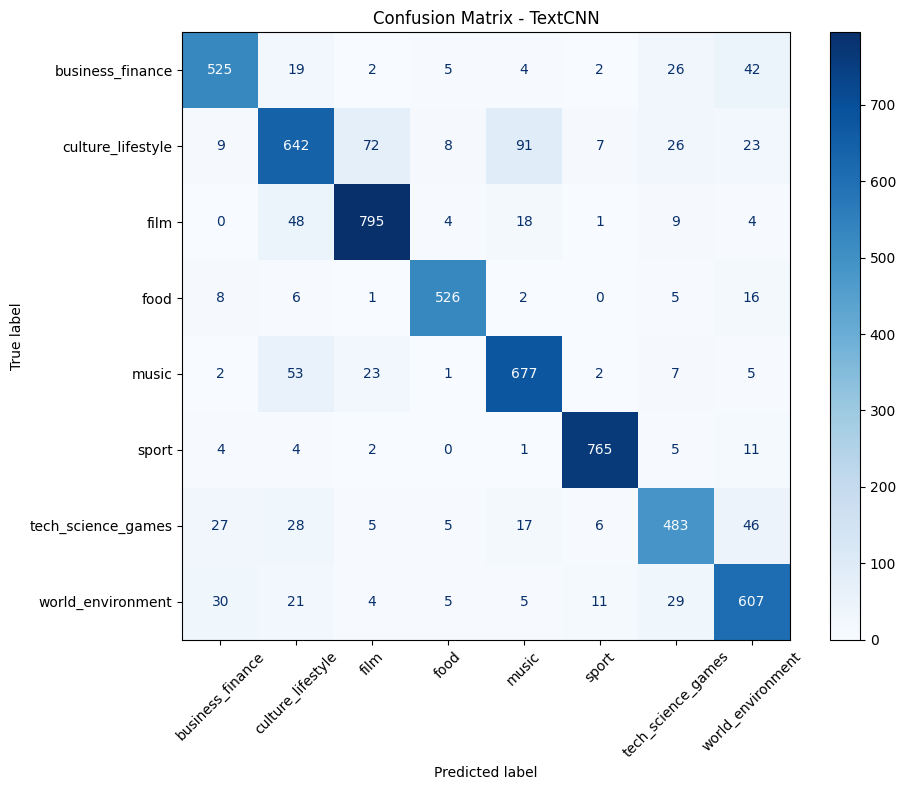

In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = label_encoder.classes_

# Tính toán các độ đo Macro
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

# Tính toán các độ đo Weighted
weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print("="*55)
print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) TẬP TEST")
print("="*55)
print(classification_report(all_labels, all_preds, target_names=target_names))

print("="*55)
print("CHI TIẾT ĐỘ ĐO MACRO VÀ WEIGHTED (PRECISION, RECALL, F1)")
print("="*55)
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")
print(f"Macro F1-score:     {macro_f1:.4f}")
print("-" * 30)
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-score:  {weighted_f1:.4f}")
print("="*55)

# Vẽ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - TextCNN')
plt.tight_layout()
plt.show()

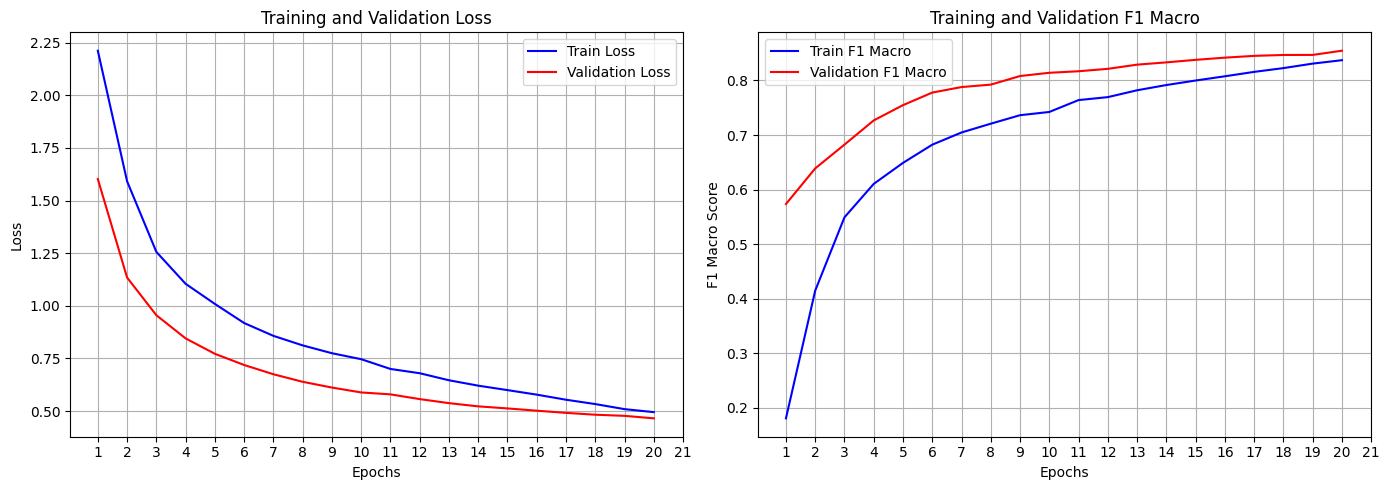

In [9]:
epochs = range(1, len(train_losses) + 1)

# --- VẼ BIỂU ĐỒ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Loss
axes[0].plot(epochs, train_losses, label='Train Loss', color='blue')
axes[0].plot(epochs, val_losses, label='Validation Loss', color='red')

axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')

# Tick theo số nguyên
axes[0].set_xticks(range(1, len(train_losses) + 2))

axes[0].legend()
axes[0].grid(True)

# Biểu đồ F1-Macro
axes[1].plot(epochs, train_f1s, label='Train F1 Macro', color='blue')
axes[1].plot(epochs, val_f1s, label='Validation F1 Macro', color='red')

axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Macro Score')
axes[1].set_title('Training and Validation F1 Macro')

# Tick theo số nguyên
axes[1].set_xticks(range(1, len(train_f1s) + 2))

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
def predict_text(text, model, word2idx, label_encoder, max_seq_length, device):
    model.eval()
    indices = text_to_indices(text, word2idx, max_seq_length)
    tensor_input = torch.tensor([indices], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(tensor_input)
        pred_idx = torch.argmax(output, dim=1).item()

    return label_encoder.inverse_transform([pred_idx])[0]

# --- Demo ---
while True:
    # Lấy dữ liệu từ người dùng nhập vào
    sample_text = input("\nNhập văn bản cần dự đoán: ")
    # Kiểm tra điều kiện thoát
    if sample_text.lower().strip() in ['q', 'quit']:
        print("Đã thoát chương trình demo.")
        break
    # Bỏ qua nếu người dùng không nhập gì mà bấm Enter
    if not sample_text.strip():
        continue

    print(f"Text: '{sample_text}'")
    print(f"Prediction: {predict_text(sample_text, model, word2idx, label_encoder, MAX_SEQ_LENGTH, device)}\n")


Nhập văn bản cần dự đoán: q
Đã thoát chương trình demo.


In [12]:
# --- Lưu Models & Dictionaries ---
save_dir = '/content/drive/MyDrive/Colab Notebooks/cs114/Model/'
os.makedirs(save_dir, exist_ok=True)

# Save Weights
torch.save(model.state_dict(), os.path.join(save_dir, 'textcnn_weights.pth'))
# Save Word2Idx
with open(os.path.join(save_dir, 'word2idx.pkl'), 'wb') as f:
    pickle.dump(word2idx, f)
# Save Label Encoder
with open(os.path.join(save_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"Đã lưu model và các file cấu hình thành công tại {save_dir}")

Đã lưu model và các file cấu hình thành công tại /content/drive/MyDrive/Colab Notebooks/cs114/Model/
